## 0. Cấu hình

In [1]:
IS_TRAIN     = True    # Bật/tắt training
IS_INFERENCE = True    # Bật/tắt inference test sau train

In [2]:
from pathlib import Path

WORKING          = Path("/kaggle/working/")
INPUT            = Path("/kaggle/input/")

# Thư mục lưu ảnh đã xử lý
FOLDER_IMAGES    = WORKING / "Viet-Chart-VQA-images"

# Đường dẫn model pretrained (sẽ download bên dưới)
MODEL_PATH       = "/kaggle/input/models/bixunhong/intern-700/other/default/1/InternVL_2"

# Thư mục output checkpoint
OUTPUT_DIR       = WORKING / "work_dirs/internvl_chat_v2_0/InternVL2_1B_lora_viet_chart_vqa"

# Thư mục lưu model sau khi merge LoRA
MERGED_OUTPUT    = WORKING / "work_dirs/internvl_chat_v2_0/InternVL2_1B_lora_viet_chart_vqa_merged"

# Đường dẫn data
# -- Dataset gốc lưu dạng HuggingFace disk
VI_CHART_DATASET_PATH = Path("/kaggle/input/datasets/maituananh511/dataset-chart-vqa/vi_chart_dataset")

# -- (Tuỳ chọn) Dataset tiếng Việt custom dạng JSONL + folder ảnh
VIETNAMESE_DATA_PATH = Path("/kaggle/input/datasets/maituananh511/data-vietnamese/Data Vietnamese")
VIETNAMESE_IMAGES_PATH = VIETNAMESE_DATA_PATH / "images"
VIETNAMESE_JSONL_PATH  = VIETNAMESE_DATA_PATH / "viet_chart_vqa.jsonl"

print("Cấu hình hoàn tất.")

Cấu hình hoàn tất.


## 1. Cài đặt thư viện

In [3]:
# Cài đặt bộ đôi tương thích hoàn hảo cho InternVL2
!pip install transformers==4.44.2 peft==0.11.1 --force-reinstall -q

# Sau khi cài xong, bạn BẮT BUỘC phải vào menu:
# Run -> Restart Session

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.4/40.4 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 807.9/807.9 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.1/801.1 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [4]:

!pip install -U -q   accelerate datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 16.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.11.0 which is incompatible.
torchvision 0.25.0+cu128 requires torch==2.10.0, but you have torch 2.11.0 which is incompatible.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [5]:
!pip install --upgrade deepspeed

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.0/54.0 kB 3.7 MB/s eta 0:00:00
  Created wheel for deepspeed: filename=deepspeed-0.18.9-py3-none-any.whl size=1820544 sha256=8f5a9dd9d45283531197ef0005e3d0169fcf04c22c67f380396c3b48dfb80897
  Stored in directory: /root/.cache/pip/wheels/14/ff/77/6df576c7f26969435706ee20282924bef2c06ec6763192d0ab
Successfully built deepspeed


In [6]:
!pip install -q packaging ninja datasets timm einops deepspeed bitsandbytes decord gdown scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 107.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cuml-cu12 26.2.0 requires cuda-toolkit[cublas,cufft,curand,cusolver,cusparse]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.
cudf-cu12 26.2.1 requires cuda-toolkit[nvcc,nvrtc]==12.*, but you have cuda-toolkit 13.0.2 which is incompatible.


In [7]:
#!pip install -q flash_attn

In [8]:


# Clone repo InternVL chính thức
!git clone https://github.com/OpenGVLab/InternVL.git {WORKING / 'InternVL'}

%cd {WORKING / 'InternVL'}
!pip install -q -e internvl_chat/

Cloning into '/kaggle/working/InternVL'...
remote: Enumerating objects: 3748, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 3748 (delta 39), reused 25 (delta 25), pack-reused 3675 (from 2)
Receiving objects: 100% (3748/3748), 39.62 MiB | 30.14 MiB/s, done.
Resolving deltas: 100% (2286/2286), done.
/kaggle/working/InternVL
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 42.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 67.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.7 MB/s eta 0:00:0

## 2. Tải dataset

In [9]:
from datasets import load_from_disk, concatenate_datasets, Dataset
import json
from PIL import Image
import pyarrow as pa

# === Load dataset HuggingFace disk ===
vi_chart_dataset = load_from_disk(str(VI_CHART_DATASET_PATH))
print("vi_chart_dataset:", vi_chart_dataset)

vi_chart_dataset: DatasetDict({
    train: Dataset({
        features: ['id', 'image', 'description', 'conversations', 'groundtruth'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['id', 'image', 'description', 'conversations', 'groundtruth'],
        num_rows: 500
    })
})


In [10]:
# === Hàm chuẩn hóa conversations ===

def normalize_turn(turn):
    """Chuẩn hóa 1 lượt hội thoại về dạng {'role': ..., 'content': ...}"""
    if isinstance(turn, str):
        return {'role': 'assistant', 'content': turn}
    if isinstance(turn, dict):
        role = turn.get('role') or turn.get('from', '')
        if role in ('human', 'user'):      role = 'user'
        elif role in ('gpt', 'assistant'): role = 'assistant'
        # Xử lý dict có key là role trực tiếp
        for rk in ('assistant', 'user', 'human', 'gpt'):
            if rk in turn and 'content' not in turn and 'role' not in turn:
                role = 'assistant' if rk in ('assistant', 'gpt') else 'user'
                return {'role': role, 'content': str(turn[rk])}
        content = str(turn.get('content') or turn.get('value', ''))
        return {'role': role, 'content': content}
    return {'role': 'assistant', 'content': str(turn)}


def align_conversations_schema(dataset, reference_dataset):
    """Đồng bộ schema Arrow của cột 'conversations' với reference dataset."""
    ref_conv_type   = reference_dataset.data.schema.field('conversations').type
    ref_struct_type = ref_conv_type.value_type
    field_order     = [ref_struct_type.field(i).name for i in range(ref_struct_type.num_fields)]

    pa_table  = dataset.data.table
    conv_arr  = pa_table.column('conversations').combine_chunks()
    struct_arr = conv_arr.values

    arrays = [struct_arr.field(f) for f in field_order]
    fields = [pa.field(f, pa.string()) for f in field_order]
    new_struct = pa.StructArray.from_arrays(arrays, fields=fields)
    new_conv   = pa.ListArray.from_arrays(conv_arr.offsets, new_struct)

    idx       = pa_table.schema.get_field_index('conversations')
    new_table = pa_table.set_column(idx, 'conversations', new_conv)
    return Dataset(new_table)

In [11]:
# === Load dataset tiếng Việt custom từ JSONL + thư mục ảnh ===
import os

vietnamese_records = []
with open(VIETNAMESE_JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            vietnamese_records.append(json.loads(line))

print(f"Vietnamese dataset: {len(vietnamese_records)} records loaded")

vn_rows = []
for record in vietnamese_records:
    img_path = VIETNAMESE_IMAGES_PATH / record['image']
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f"[WARN] Không đọc được ảnh {img_path}: {e}")
        continue

    convs = [normalize_turn(t) for t in record['conversations']]
    pairs = [(convs[i], convs[i+1]) for i in range(0, len(convs) - 1, 2)]

    for idx, (q, a) in enumerate(pairs):
        record_id = record['id'] if len(pairs) == 1 else f"{record['id']}_q{idx}"
        vn_rows.append({
            'id': record_id,
            'image': image,
            'conversations': [q, a],
        })

print(f"Vietnamese rows: {len(vn_rows)}")

TEST_SIZE     = 200
vn_train_rows = vn_rows[:-TEST_SIZE]
vn_test_rows  = vn_rows[-TEST_SIZE:]

vi_vietnamese_train = Dataset.from_list(vn_train_rows)
vi_vietnamese_test  = Dataset.from_list(vn_test_rows)

vi_vietnamese_train = align_conversations_schema(vi_vietnamese_train, vi_chart_dataset['train'])
vi_vietnamese_test  = align_conversations_schema(vi_vietnamese_test,  vi_chart_dataset['test'])

# Shuffle và lấy 30k mẫu từ dataset gốc
vi_chart_30k = vi_chart_dataset['train'].shuffle(seed=42, keep_in_memory=True).select(range(30000))

merged_train = concatenate_datasets([vi_chart_30k, vi_vietnamese_train])
merged_test  = concatenate_datasets([vi_chart_dataset['test'], vi_vietnamese_test])

vi_chart_dataset['train'] = merged_train
vi_chart_dataset['test']  = merged_test

print(f"\nTổng train: {len(vi_chart_dataset['train'])}")
print(f"Tổng test : {len(vi_chart_dataset['test'])}")

Vietnamese dataset: 4957 records loaded


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Vietnamese rows: 14871

Tổng train: 44671
Tổng test : 700


In [12]:
# Xem thử 1 mẫu
sample = vi_chart_dataset['train'][0]
print("ID:", sample['id'])
print("Image size:", sample['image'].size)
print("Conversations:", sample['conversations'])

ID: 860ed9c6cfe9296b2092
Image size: (448, 448)
Conversations: [{'content': "Nếu thêm một nhóm 'easy' có giá trị là 15, thì nhóm nào có giá trị thấp nhất?", 'role': 'user'}, {'content': "Nếu thêm nhóm 'easy' với giá trị 15, nhóm có giá trị thấp nhất sẽ là 'easy'.", 'role': 'assistant'}]


## 3. Tải model InternVL2-1B

In [13]:
from pathlib import Path

# Đảm bảo MODEL_PATH là đối tượng Path
MODEL_PATH = Path(MODEL_PATH) 

# Bây giờ phép toán / sẽ hoạt động bình thường
with open(MODEL_PATH / 'config.json') as f:
    cfg = json.load(f)

CONV_STYLE = cfg.get('template', 'internlm2-chat')
print(f"conv_style: {CONV_STYLE}")

conv_style: Hermes-2


## 4. Hàm tiện ích xử lý ảnh

In [14]:
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image
from torchvision.transforms.functional import InterpolationMode
from transformers import AutoModel, AutoTokenizer

In [15]:


IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def build_transform(input_size):
    return T.Compose([
        T.Lambda(lambda img: img.convert('RGB') if img.mode != 'RGB' else img),
        T.Resize((input_size, input_size), interpolation=InterpolationMode.BICUBIC),
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])


def find_closest_aspect_ratio(aspect_ratio, target_ratios, width, height, image_size):
    best_ratio_diff = float('inf')
    best_ratio      = (1, 1)
    area            = width * height
    for ratio in target_ratios:
        target_ar   = ratio[0] / ratio[1]
        ratio_diff  = abs(aspect_ratio - target_ar)
        if ratio_diff < best_ratio_diff:
            best_ratio_diff = ratio_diff
            best_ratio      = ratio
        elif ratio_diff == best_ratio_diff:
            if area > 0.5 * image_size * image_size * ratio[0] * ratio[1]:
                best_ratio = ratio
    return best_ratio


def dynamic_preprocess(image, min_num=1, max_num=12, image_size=448, use_thumbnail=False):
    orig_width, orig_height = image.size
    aspect_ratio            = orig_width / orig_height
    target_ratios           = set(
        (i, j) for n in range(min_num, max_num + 1)
        for i in range(1, n + 1) for j in range(1, n + 1)
        if i * j <= max_num and i * j >= min_num
    )
    target_ratios = sorted(target_ratios, key=lambda x: x[0] * x[1])
    target_ar     = find_closest_aspect_ratio(
        aspect_ratio, target_ratios, orig_width, orig_height, image_size)
    target_w      = image_size * target_ar[0]
    target_h      = image_size * target_ar[1]
    blocks        = target_ar[0] * target_ar[1]
    resized_img   = image.resize((target_w, target_h))
    processed     = []
    for i in range(blocks):
        box = (
            (i % (target_w  // image_size)) * image_size,
            (i // (target_w // image_size)) * image_size,
            ((i % (target_w  // image_size)) + 1) * image_size,
            ((i // (target_w // image_size)) + 1) * image_size,
        )
        processed.append(resized_img.crop(box))
    assert len(processed) == blocks
    if use_thumbnail and len(processed) != 1:
        processed.append(image.resize((image_size, image_size)))
    return processed


def load_image(image_file, input_size=448, max_num=12):
    image = Image.open(image_file).convert('RGB') if isinstance(image_file, str) else image_file
    transform    = build_transform(input_size=input_size)
    images       = dynamic_preprocess(image, image_size=input_size, use_thumbnail=True, max_num=max_num)
    pixel_values = torch.stack([transform(img) for img in images])
    return pixel_values


print("✅ Đã định nghĩa các hàm xử lý ảnh.")

✅ Đã định nghĩa các hàm xử lý ảnh.


## 5. Kiểm tra model trước khi fine-tune (inference thô)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


FlashAttention is not installed.
 Tải model pretrained thành công.


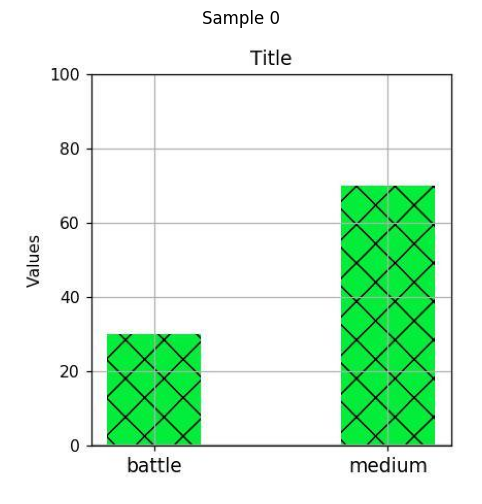

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Q   : Nếu thêm một nhóm 'easy' có giá trị là 15, thì nhóm nào có giá trị thấp nhất?
Pred: battle và medium có giá trị thấp nhất là 30 và 70, respectively.
GT  : Nếu thêm nhóm 'easy' với giá trị 15, nhóm có giá trị thấp nhất sẽ là 'easy'.


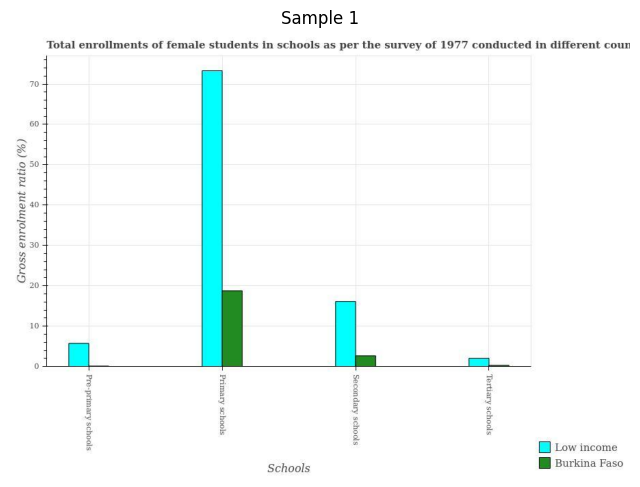

Token indices sequence length is longer than the specified maximum sequence length for this model (1867 > 700). Running this sequence through the model will result in indexing errors
Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Q   : Nếu xu hướng này tiếp tục, bạn dự đoán tỷ lệ nhập học của nữ sinh sẽ ra sao trong tương lai?
Pred: Để dự đoán tỷ lệ nhập học của nữ sinh sẽ ra sao trong tương lai, một số yếu tố cần được phân tích và xác định. Đầu tiên, cần hiểu rõ về sự tiến bộ và phát triển của các quốc gia trong thời gian qua. Sau đây, chúng ta sẽ phân tích dữ liệu để tìm hiểu về tình trạng hiện tại của người phụ nữ ở các quốc gia và dự đoán tương lai.

1. Các quốc gia đã thực hiện cải thiện đáng kể trong việc giảm bớt tỷ lệ thiếu giáo dục cho nữ sinh.
2. Các quốc gia đã tăng cường đào tạo và nâng cao chất lượng giáo dục.
3. Các quốc gia đã mở rộng cơ sở vật chất và kỹ thuật để hỗ trợ việc tiếp cận giáo dục.
4. Các quốc gia đã đầu tư vào nghiên cứu và phát triển kinh tế mạnh mẽ để đảm bảo sự ổn định và phát triển của đất nước.
5. Các quốc gia đã xây dựng chính quyền mạnh mẽ và có trách nhiệm trong việc đảm bảo quyền lợi của người phụ nữ.
6. Các quốc gia đã áp dụng chính sách chăm sóc sức khỏe và phòng ngừa bện

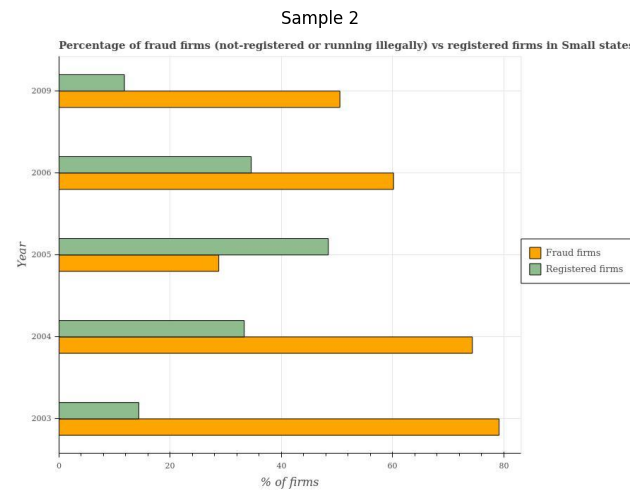

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.


Q   : Có sự khác biệt rõ rệt về tỷ lệ doanh nghiệp gian lận và doanh nghiệp đã đăng ký trong các năm từ 2003 đến 2009 không?
Pred: Để xác định sự khác biệt rõ rệt về tỷ lệ doanh nghiệp gian lận và doanh nghiệp đã đăng ký trong các năm từ 2003 đến 2009 không, chúng ta cần phân tích dữ liệu theo từng năm. 

1. Năm 2003:
   - Doanh nghiệp gian lận chiếm khoảng 78%.
   - Doanh nghiệp đã đăng ký chiếm khoảng 14%.

2. Năm 2004:
   - Doanh nghiệp gian lận chiếm khoảng 75%.
   - Doanh nghiệp đã đăng ký chiếm khoảng 30%.

3. Năm 2005:
   - Doanh nghiệp gian lận chiếm khoảng 28%.
   - Doanh nghiệp đã đăng ký chiếm khoảng 45%.

4. Năm 2006:
   - Doanh nghiệp gian lận chiếm khoảng 60%.
   - Doanh nghiệp đã đăng ký chiếm khoảng 35%.

5. Năm 2009:
   - Doanh nghiệp gian lận chiếm khoảng 50%.
   - Doanh nghiệp đã đăng ký chiếm khoảng 10%.

Đầu tiên, chúng ta thấy rằng vào năm 2003 và 2004, tỷ lệ doanh nghiệp gian lận và doanh nghiệp đã đăng ký giảm đi một chút nhưng vẫn ở mức cao. Trong khi đó, vào n

In [16]:
import matplotlib.pyplot as plt
import torch # Đảm bảo bạn đã import torch

tokenizer      = AutoTokenizer.from_pretrained(str(MODEL_PATH), trust_remote_code=True, use_fast=False)
pretrain_model = AutoModel.from_pretrained(
    str(MODEL_PATH),
    torch_dtype=torch.float16,  
    low_cpu_mem_usage=True,
    trust_remote_code=True,
    #attn_implementation="eager"  
).eval().cuda()

print(" Tải model pretrained thành công.")
generation_config = dict(max_new_tokens=512, do_sample=False, num_beams=3, repetition_penalty=2.0)

for i in range(min(3, len(vi_chart_dataset['train']))):
    item  = vi_chart_dataset['train'][i]
    image = item['image']
    convs = item['conversations']
    question_text = str(convs[0].get('content') or convs[0].get('value', ''))
    gt            = str(convs[1].get('content') or convs[1].get('value', ''))

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Sample {i}")
    plt.show()

  
    pixel_values = load_image(image, max_num=6).to(torch.float16).cuda()
    question     = f'<image>\n{question_text}'
    response     = pretrain_model.chat(tokenizer, pixel_values, question, generation_config)

    print(f"Q   : {question_text}")
    print(f"Pred: {response}")
    print(f"GT  : {gt}")
    print('=' * 60)

# Giải phóng VRAM
del pretrain_model
torch.cuda.empty_cache()

## 6. Chuẩn bị dữ liệu training (JSONL + meta JSON)

In [17]:
from tqdm import tqdm

os.makedirs(FOLDER_IMAGES, exist_ok=True)

# Lưu ảnh xuống disk, resize 448×448 để tiết kiệm VRAM
for i in tqdm(range(len(vi_chart_dataset['train'])), desc="Saving images"):
    item  = vi_chart_dataset['train'][i]
    image = item['image']
    id    = item['id']
    image.resize((448, 448)).save(f"{FOLDER_IMAGES}/{id}.jpg")

print(f" Đã lưu {len(vi_chart_dataset['train'])} ảnh vào {FOLDER_IMAGES}")

Saving images: 100%|██████████| 44671/44671 [05:56<00:00, 125.21it/s]

 Đã lưu 44671 ảnh vào /kaggle/working/Viet-Chart-VQA-images


In [18]:
def normalize_conversations(conversations):
    """Chuẩn hóa conversations về dạng [{'from': 'human'/'gpt', 'value': ...}]"""
    role_map = {'human': 'human', 'user': 'human', 'gpt': 'gpt', 'assistant': 'gpt'}
    result   = []
    for turn in conversations:
        raw_role = turn.get('from') or turn.get('role', '')
        role     = role_map.get(str(raw_role).lower(), raw_role)
        value    = str(turn.get('content') or turn.get('value', ''))
        result.append({'from': role, 'value': value})
    return result


all_data = []
for item in tqdm(vi_chart_dataset['train'], desc="Building JSONL"):
    id     = item['id']
    width  = item['image'].width
    height = item['image'].height
    normalized_convs = normalize_conversations(item['conversations'])

    for i in range(0, len(normalized_convs), 2):
        if i + 1 < len(normalized_convs):
            all_data.append({
                "id":    id,
                "image": f"{id}.jpg",
                "width": width,
                "height": height,
                "conversations": [
                    {"from": "human", "value": normalized_convs[i]['value']},
                    {"from": "gpt",   "value": normalized_convs[i + 1]['value']}
                ]
            })

print(f"✅ Tổng mẫu training: {len(all_data)}")
print("\nVí dụ 2 mẫu đầu:")
print(json.dumps(all_data[:2], indent=2, ensure_ascii=False))

Building JSONL: 100%|██████████| 44671/44671 [01:12<00:00, 619.57it/s]

✅ Tổng mẫu training: 44671

Ví dụ 2 mẫu đầu:
[
  {
    "id": "860ed9c6cfe9296b2092",
    "image": "860ed9c6cfe9296b2092.jpg",
    "width": 448,
    "height": 448,
    "conversations": [
      {
        "from": "human",
        "value": "Nếu thêm một nhóm 'easy' có giá trị là 15, thì nhóm nào có giá trị thấp nhất?"
      },
      {
        "from": "gpt",
        "value": "Nếu thêm nhóm 'easy' với giá trị 15, nhóm có giá trị thấp nhất sẽ là 'easy'."
      }
    ]
  },
  {
    "id": "12de5106977e228ad52a",
    "image": "12de5106977e228ad52a.jpg",
    "width": 906,
    "height": 650,
    "conversations": [
      {
        "from": "human",
        "value": "Nếu xu hướng này tiếp tục, bạn dự đoán tỷ lệ nhập học của nữ sinh sẽ ra sao trong tương lai?"
      },
      {
        "from": "gpt",
        "value": "Khó để dự đoán chính xác xu hướng trong tương lai mà không có thông tin bổ sung về chính sách giáo dục, điều kiện xã hội kinh tế, và sự thay đổi trong các yếu tố khác. Tuy nhiên, có thể d

In [19]:
# Ghi JSONL annotation
JSONL_PATH = WORKING / 'InternVL/internvl_chat/shell/data/viet-chart-vqa.jsonl'
os.makedirs(JSONL_PATH.parent, exist_ok=True)

with open(JSONL_PATH, 'w', encoding='utf-8') as f:
    for data in tqdm(all_data, desc="Writing JSONL"):
        f.write(json.dumps(data, ensure_ascii=False) + '\n')

print(f" Đã lưu JSONL: {JSONL_PATH}")

# Ghi meta JSON (danh sách dataset)
META_PATH = WORKING / 'InternVL/internvl_chat/shell/data/custom_finetune_datasets.json'

metadata_datasets = {
    "vi-chart-vqa": {
        "root":         str(FOLDER_IMAGES),
        "annotation":   str(JSONL_PATH),
        "data_augment": False,
        "repeat_time":  1,
        "length":       len(vi_chart_dataset['train'])
    }
}

with open(META_PATH, 'w', encoding='utf-8') as f:
    json.dump(metadata_datasets, f, ensure_ascii=False, indent=4)

print(f"✅ Đã lưu meta JSON: {META_PATH}")

Writing JSONL: 100%|██████████| 44671/44671 [00:00<00:00, 106141.15it/s]

 Đã lưu JSONL: /kaggle/working/InternVL/internvl_chat/shell/data/viet-chart-vqa.jsonl
✅ Đã lưu meta JSON: /kaggle/working/InternVL/internvl_chat/shell/data/custom_finetune_datasets.json


## 8. Tạo script training (LoRA finetune)

In [20]:
# =========================================================
# ĐIỀU CHỈNH CÁC SIÊU THAM SỐ TẠI ĐÂY
# =========================================================

NUM_GPUS                  = 1    # Số GPU sử dụng
PER_DEVICE_TRAIN_BATCH    = 1      # Batch size mỗi GPU
GRADIENT_ACC_STEPS        = 64    # Gradient accumulation (effective batch = GPU * per_device * grad_acc)
NUM_TRAIN_EPOCHS          = 1      # Số epoch
LEARNING_RATE             = 2e-4   # Learning rate
LORA_RANK                 = 16     # Rank LoRA adapter
MAX_SEQ_LENGTH            = 512    # Độ dài sequence tối đa
MAX_DYNAMIC_PATCH         = 4    # Số patch động tối đa
SAVE_STEPS                = 500    # Lưu checkpoint mỗi N steps
LOGGING_STEPS             = 10     # Log mỗi N steps
USE_BF16                  = False  # True nếu GPU hỗ trợ BF16 (A100/H100)
USE_FP16                  = True   # Dùng FP16 nếu không có BF16

# Freeze options: True = đóng băng, False = train thêm (tốn VRAM hơn)
FREEZE_BACKBONE           = True   # Đóng băng visual encoder
FREEZE_MLP                = True   # Đóng băng MLP connector
FREEZE_LLM                = True   # Đóng băng LLM body (chỉ train LoRA)

print(f"Effective batch size: {NUM_GPUS} GPU × {PER_DEVICE_TRAIN_BATCH} × {GRADIENT_ACC_STEPS} acc = {NUM_GPUS * PER_DEVICE_TRAIN_BATCH * GRADIENT_ACC_STEPS}")

Effective batch size: 1 GPU × 1 × 64 acc = 64


In [21]:
TRAIN_SH_PATH = WORKING / 'InternVL/internvl_chat/shell/internvl2.0/2nd_finetune/internvl2_1b_lora_viet_chart_vqa.sh'
os.makedirs(TRAIN_SH_PATH.parent, exist_ok=True)

# Ép FP16 để chạy được trên P100/T4
bf16_flag = 'False'
fp16_flag = 'True'

train_bash_content = f"""#!/bin/bash
set -x

export PYTHONPATH="$PYTHONPATH:$(pwd)"
export TF_CPP_MIN_LOG_LEVEL=3

OUTPUT_DIR="{OUTPUT_DIR}"
mkdir -p "$OUTPUT_DIR"

# DÙNG TORCHRUN ĐỂ CHẠY 2x T4 (Tự động cấp RANK/WORLD_SIZE)
torchrun --nproc_per_node=2 --master_port=29501 \\
  internvl/train/internvl_chat_finetune.py \\
  --model_name_or_path "{MODEL_PATH}" \\
  --conv_style "{CONV_STYLE}" \\
  --output_dir "$OUTPUT_DIR" \\
  --meta_path "{META_PATH}" \\
  --overwrite_output_dir True \\
  --force_image_size 336 \\
  --max_dynamic_patch 4 \\
  --down_sample_ratio 0.5 \\
  --drop_path_rate 0.0 \\
  --freeze_llm {FREEZE_LLM} \\
  --freeze_mlp {FREEZE_MLP} \\
  --freeze_backbone {FREEZE_BACKBONE} \\
  --use_llm_lora {LORA_RANK} \\
  --vision_select_layer -1 \\
  --dataloader_num_workers 2 \\
  --bf16 {bf16_flag} \\
  --fp16 {fp16_flag} \\
  --num_train_epochs {NUM_TRAIN_EPOCHS} \\
  --per_device_train_batch_size {PER_DEVICE_TRAIN_BATCH} \\
  --gradient_accumulation_steps {GRADIENT_ACC_STEPS} \\
  --evaluation_strategy no \\
  --save_strategy steps \\
  --save_steps {SAVE_STEPS} \\
  --save_total_limit 2 \\
  --learning_rate {LEARNING_RATE} \\
  --weight_decay 0.01 \\
  --warmup_ratio 0.03 \\
  --lr_scheduler_type "cosine" \\
  --logging_steps 10 \\
  --max_seq_length 512 \\
  --do_train True \\
  --grad_checkpointing True \\
  --group_by_length True \\
  --dynamic_image_size True \\
  --use_thumbnail True \\
  --ps_version v2 \\
  --launcher "pytorch" \\
  --report_to "none" \\
  2>&1 | tee -a "$OUTPUT_DIR/training_log.txt"
"""

with open(TRAIN_SH_PATH, 'w') as f:
    f.write(train_bash_content)

print(f"✅ Script training đã FIX LỖI lưu tại: {TRAIN_SH_PATH}")

✅ Script training đã FIX LỖI lưu tại: /kaggle/working/InternVL/internvl_chat/shell/internvl2.0/2nd_finetune/internvl2_1b_lora_viet_chart_vqa.sh


## 9. Chạy Training

In [22]:
!pip install -U "setuptools<70.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 894.6/894.6 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: setuptools
    Found existing installation: setuptools 81.0.0
    Uninstalling setuptools-81.0.0:
      Successfully uninstalled setuptools-81.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.


In [23]:
# Chặn đứng việc nạp deepspeed trong mã nguồn InternVL
!sed -i 's/import deepspeed/# import deepspeed/g' /kaggle/working/InternVL/internvl_chat/internvl/dist_utils.py

# Chặn các dòng gọi đến deepspeed trong dist_utils.py để tránh lỗi name 'deepspeed' is not defined
!sed -i 's/if deepspeed.checkpoint/# if False/g' /kaggle/working/InternVL/internvl_chat/internvl/dist_utils.py

print("✅ Đã vô hiệu hóa DeepSpeed. Bây giờ script sẽ không bị crash khi khởi động nữa.")

✅ Đã vô hiệu hóa DeepSpeed. Bây giờ script sẽ không bị crash khi khởi động nữa.


In [24]:
# Cài đặt lại torchvision đồng bộ với bản CUDA 13.0 của hệ thống
!pip install --no-cache-dir torchvision --index-url https://download.pytorch.org/whl/cu130 --force-reinstall -q



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 277.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 268.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 250.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 236.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 253.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 297.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 251.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 337.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 270.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 256.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 220.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.9/145.9 MB 278.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [25]:
import os

# Đường dẫn các file (đảm bảo đúng cấu trúc folder của bạn)
PATH_PATCH_DIR = "/kaggle/working/InternVL/internvl_chat/internvl/patch"
PATH_TRAIN_FILE = "/kaggle/working/InternVL/internvl_chat/internvl/train/internvl_chat_finetune.py"

# --- 1. Fix llama_packed_training_patch.py ---
fix_llama_patch = """
import warnings

try:
    from flash_attn.flash_attn_interface import flash_attn_varlen_func
    HAS_FLASH_ATTN = True
except ImportError:
    HAS_FLASH_ATTN = False

def replace_llama_attention_class():
    if not HAS_FLASH_ATTN:
        warnings.warn("FlashAttention không được cài đặt. Bỏ qua việc thay thế Llama Attention.")
        return
    # Code gốc ở đây nếu có Flash Attention sẽ chạy tiếp...
    print("FlashAttention detected. Patching Llama...")
"""
with open(os.path.join(PATH_PATCH_DIR, "llama_packed_training_patch.py"), "w") as f:
    f.write(fix_llama_patch)

# --- 2. Fix __init__.py (trong folder patch) ---
fix_init = """
import warnings

def safe_import_patch(patch_name, func_name):
    try:
        module = __import__(f".{patch_name}", globals(), locals(), [func_name], 1)
        return getattr(module, func_name)
    except (ImportError, AttributeError, ModuleNotFoundError):
        # Trả về một hàm trống (no-op) nếu không import được
        return lambda: None

# Vô hiệu hóa các patch gây lỗi Flash Attention
replace_llama_attention_class = safe_import_patch("llama_packed_training_patch", "replace_llama_attention_class")
replace_llama2_attn_with_flash_attn = safe_import_patch("llama2_flash_attn_monkey_patch", "replace_llama2_attn_with_flash_attn")
replace_internlm2_attention_class = safe_import_patch("internlm2_packed_training_patch", "replace_internlm2_attention_class")
concat_pad_data_collator = safe_import_patch("pad_data_collator", "concat_pad_data_collator")
"""
with open(os.path.join(PATH_PATCH_DIR, "__init__.py"), "w") as f:
    f.write(fix_init)

# --- 3. Fix internvl_chat_finetune.py ---
with open(PATH_TRAIN_FILE, 'r') as f:
    lines = f.readlines()

with open(PATH_TRAIN_FILE, 'w') as f:
    for line in lines:
        # Tìm và comment các dòng lệnh kích hoạt patch
        if "replace_llama_attention_class()" in line or \
           "replace_llama2_attn_with_flash_attn()" in line or \
           "replace_internlm2_attention_class()" in line:
            f.write(f"    # {line.strip()} # Đã vô hiệu hóa để chạy trên T4\\n")
        else:
            f.write(line)

print("✅ Đã FIX xong 3 file. 'Con ma' Flash Attention đã bị trục xuất!")

✅ Đã FIX xong 3 file. 'Con ma' Flash Attention đã bị trục xuất!


In [26]:
import os

PATH_PATCH_INIT = "/kaggle/working/InternVL/internvl_chat/internvl/patch/__init__.py"

# Nội dung file __init__.py "siêu an toàn" hỗ trợ mọi hàm mà script training yêu cầu
fix_init_v3 = """
import warnings

def safe_import_patch(patch_name, func_name):
    try:
        # Thử nạp module từ file tương ứng
        module = __import__(f".{patch_name}", globals(), locals(), [func_name], 1)
        return getattr(module, func_name)
    except (ImportError, AttributeError, ModuleNotFoundError):
        # Nếu lỗi (thiếu Flash Attention...), trả về một hàm rỗng để script không crash
        return lambda *args, **kwargs: None

# 1. Khai báo danh sách các hàm mà script Train (internvl_chat_finetune.py) yêu cầu
replace_llama_attention_class = safe_import_patch("llama_packed_training_patch", "replace_llama_attention_class")
replace_llama2_attn_with_flash_attn = safe_import_patch("llama2_flash_attn_monkey_patch", "replace_llama2_attn_with_flash_attn")
replace_llama_attn_with_flash_attn = safe_import_patch("llama_flash_attn_monkey_patch", "replace_llama_attn_with_flash_attn")
replace_internlm2_attention_class = safe_import_patch("internlm2_packed_training_patch", "replace_internlm2_attention_class")
replace_phi3_attention_class = safe_import_patch("phi3_packed_training_patch", "replace_phi3_attention_class")
replace_qwen2_attention_class = safe_import_patch("qwen2_packed_training_patch", "replace_qwen2_attention_class")

# 2. Các hàm tối ưu hóa hệ thống (RMSNorm, Dataloader)
# Hàm này gây lỗi ImportError bạn vừa gặp - giờ đã được khai báo an toàn
replace_llama_rmsnorm_with_fused_rmsnorm = safe_import_patch("llama_rmsnorm_monkey_patch", "replace_llama_rmsnorm_with_fused_rmsnorm")
replace_train_dataloader = safe_import_patch("train_dataloader_patch", "replace_train_dataloader")
replace_train_sampler = safe_import_patch("train_sampler_patch", "replace_train_sampler")

# 3. Xử lý Data Collator (Quan trọng để nạp dữ liệu)
try:
    from .pad_data_collator import concat_pad_data_collator, pad_data_collator, dpo_concat_pad_data_collator
except ImportError:
    from transformers import default_data_collator
    concat_pad_data_collator = default_data_collator
    pad_data_collator = default_data_collator
    dpo_concat_pad_data_collator = default_data_collator

# Xuất bản tất cả các tên hàm ra ngoài để script Train thấy được
__all__ = [
    'replace_llama_attn_with_flash_attn',
    'replace_llama_rmsnorm_with_fused_rmsnorm',
    'replace_llama2_attn_with_flash_attn',
    'replace_train_sampler',
    'replace_train_dataloader',
    'replace_internlm2_attention_class',
    'replace_qwen2_attention_class',
    'replace_phi3_attention_class',
    'replace_llama_attention_class',
    'concat_pad_data_collator'
]
"""

with open(PATH_PATCH_INIT, "w") as f:
    f.write(fix_init_v3)

print("✅ Đã ghi đè file __init__.py. Lỗi 'cannot import name' đã được giải quyết triệt để!")

✅ Đã ghi đè file __init__.py. Lỗi 'cannot import name' đã được giải quyết triệt để!


In [27]:
import builtins

In [28]:
import os

file_path = "/kaggle/working/InternVL/internvl_chat/internvl/train/internvl_chat_finetune.py"

standard_huggingface_code = """
import os
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ["BNB_CUDA_VERSION"] = "121"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import torch.distributed as dist
from dataclasses import dataclass, field
from typing import Optional
from transformers import (AutoTokenizer, HfArgumentParser, Trainer, TrainingArguments)
from internvl.model.internvl_chat import InternVLChatConfig, InternVLChatModel
from internvl.patch import (concat_pad_data_collator)
from internvl.train.dataset import (build_transform, preprocess, preprocess_internlm, preprocess_mpt)
from torch.utils.data import Dataset, ConcatDataset
import json
from copy import deepcopy

IMG_CONTEXT_TOKEN = '<IMG_CONTEXT>'

@dataclass
class ModelArguments:
    model_name_or_path: Optional[str] = field(default=None)
    use_llm_lora: int = field(default=0)
    freeze_llm: bool = field(default=True)
    freeze_mlp: bool = field(default=True)
    freeze_backbone: bool = field(default=True)
    vision_select_layer: int = field(default=-1)
    grad_checkpointing: bool = field(default=True) 
    launcher: str = field(default='pytorch')
    drop_path_rate: float = field(default=0.0)
    ps_version: str = field(default='v2')

@dataclass
class DataTrainingArguments:
    max_seq_length: int = field(default=512)
    force_image_size: int = field(default=336)
    down_sample_ratio: float = field(default=0.5) 
    max_dynamic_patch: int = field(default=1)
    meta_path: str = field(default=None)
    conv_style: str = field(default='internlm2-chat')
    dynamic_image_size: bool = field(default=False)
    use_thumbnail: bool = field(default=False)

class LazySupervisedDataset(Dataset):
    def __init__(self, template_name, meta, tokenizer, ds_name, num_image_token, image_size=336):
        super().__init__()
        self.tokenizer, self.template_name = tokenizer, template_name
        self.num_image_token = num_image_token
        self.root = meta['root']
        with open(meta['annotation'], 'r') as f: self.raw_data = f.readlines()
        self.image_size = image_size

    def __len__(self): return len(self.raw_data)
    def __getitem__(self, i):
        data_item = json.loads(self.raw_data[i])
        from PIL import Image
        image = Image.open(os.path.join(self.root, data_item['image'])).convert('RGB').resize((self.image_size, self.image_size))
        transform = build_transform(is_train=True, input_size=self.image_size)
        pixel_values = torch.stack([transform(image)])
        convs = deepcopy(data_item['conversations'])
        if '<image>' not in convs[0]['value']: convs[0]['value'] = '<image>\\\\n' + convs[0]['value']
        pre_func = preprocess_mpt if self.template_name == 'Hermes-2' else (preprocess_internlm if self.template_name == 'internlm2-chat' else preprocess)
        ret = pre_func(self.template_name, [convs], self.tokenizer, [self.num_image_token])
        return dict(input_ids=ret['input_ids'][0], labels=ret['labels'][0], attention_mask=ret['attention_mask'][0], pixel_values=pixel_values, image_flags=torch.tensor([1]))

def main():
    if 'RANK' in os.environ: dist.init_process_group(backend='nccl')
    else: dist.init_process_group(backend='nccl', rank=0, world_size=1)

    parser = HfArgumentParser((ModelArguments, DataTrainingArguments, TrainingArguments))
    model_args, data_args, training_args = parser.parse_args_into_dataclasses()

    tokenizer = AutoTokenizer.from_pretrained(model_args.model_name_or_path, trust_remote_code=True)
    tokenizer.model_max_length = data_args.max_seq_length
    tokenizer.add_tokens([IMG_CONTEXT_TOKEN], special_tokens=True)
    
    config = InternVLChatConfig.from_pretrained(model_args.model_name_or_path)
    if isinstance(config, tuple): config = config[0]
    
    if hasattr(config, 'vision_config'):
        config.vision_config.image_size = data_args.force_image_size
    
    config.max_seq_length = data_args.max_seq_length
    if hasattr(config, 'llm_config'):
        config.llm_config.max_position_embeddings = data_args.max_seq_length
        config.llm_config.model_max_length = data_args.max_seq_length
        config.llm_config._attn_implementation = 'eager'

    # 🛑 SỬA LỖI TẬN GỐC TẠI ĐÂY: Dùng float32 để tương thích 100% với GradScaler
    model = InternVLChatModel.from_pretrained(
        model_args.model_name_or_path, 
        torch_dtype=torch.float32, 
        config=config, 
        attn_implementation='eager',
        ignore_mismatched_sizes=True
    )
    
    model.language_model.resize_token_embeddings(len(tokenizer))
    model.img_context_token_id = tokenizer.convert_tokens_to_ids(IMG_CONTEXT_TOKEN)
    model.num_image_token = 144 

    ds_meta = json.loads(open(data_args.meta_path).read())
    datasets = [LazySupervisedDataset(data_args.conv_style, ds_meta[name], tokenizer, name, 144, image_size=data_args.force_image_size) for name in ds_meta.keys()]
    
    if model_args.use_llm_lora:
        model.wrap_llm_lora(r=model_args.use_llm_lora, lora_alpha=2 * model_args.use_llm_lora)

    model.gradient_checkpointing_enable()
    model.language_model.config.use_cache = False

    # Đã xóa sạch các đoạn hack "scaler = None"
    trainer = Trainer(model=model, args=training_args, train_dataset=ConcatDataset(datasets), data_collator=concat_pad_data_collator, tokenizer=tokenizer)
    # 🛑 BỘ LỌC SPAM: Chặn dòng chữ "dynamic ViT batch size"
    import builtins
    original_print = builtins.print

    def filtered_print(*args, **kwargs):
        # Nếu nội dung in ra có chứa cụm từ spam thì bỏ qua không in
        if args and isinstance(args[0], str) and 'dynamic ViT batch size' in args[0]:
            return 
        # Còn lại thì in bình thường
        original_print(*args, **kwargs)

    # Ghi đè hàm print mặc định của Python
    builtins.print = filtered_print
    trainer.train()

if __name__ == '__main__': main()
"""

with open(file_path, "w") as f:
    f.write(standard_huggingface_code)
print("✅ Đã làm sạch code, nạp model bằng float32 để sửa dứt điểm lỗi GradScaler!")

✅ Đã làm sạch code, nạp model bằng float32 để sửa dứt điểm lỗi GradScaler!


In [29]:
import os

file_path = "/kaggle/working/InternVL/internvl_chat/internvl/train/internvl_chat_finetune.py"

if os.path.exists(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    with open(file_path, 'w') as f:
        # Chèn lệnh fix LD_LIBRARY_PATH ngay đầu file
        f.write("import os\n")
        f.write("os.environ['LD_LIBRARY_PATH'] = os.environ.get('LD_LIBRARY_PATH', '') + ':/usr/local/cuda/lib64'\n")
        
        for line in lines:
            # Xóa các dòng import os cũ để tránh trùng lặp nếu cần
            if line.strip() == "import os": continue
            f.write(line)
            
    print("✅ Đã vá LD_LIBRARY_PATH trực tiếp vào file finetune.py.")

✅ Đã vá LD_LIBRARY_PATH trực tiếp vào file finetune.py.


In [30]:
import os

# 1. Nâng cấp bitsandbytes lên bản vá lỗi
!pip install -U bitsandbytes --quiet

# 2. Thiết lập đường dẫn thư viện CUDA chuẩn cho Kaggle
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')

# 3. Ép bitsandbytes sử dụng CUDA 12 (Tránh lỗi tìm kiếm bản .13)
os.environ["BNB_CUDA_VERSION"] = "121" 

print("✅ Đã cấu hình môi trường CUDA chuẩn cho T4!")

✅ Đã cấu hình môi trường CUDA chuẩn cho T4!


In [31]:
import os

# 1. Cài đặt lại DeepSpeed để sửa file bị lỗi cú pháp
!pip uninstall -y deepspeed
!pip install deepspeed --quiet

# 2. Đảm bảo bitsandbytes và CUDA vẫn ổn định như bước trước
!pip install -U bitsandbytes --quiet
os.environ['LD_LIBRARY_PATH'] = '/usr/local/cuda/lib64:' + os.environ.get('LD_LIBRARY_PATH', '')
os.environ["BNB_CUDA_VERSION"] = "121"

print("✅ Đã cài đặt lại DeepSpeed sạch sẽ. Lỗi IndentationError sẽ biến mất.")

Found existing installation: deepspeed 0.18.9
Uninstalling deepspeed-0.18.9:
  Successfully uninstalled deepspeed-0.18.9
✅ Đã cài đặt lại DeepSpeed sạch sẽ. Lỗi IndentationError sẽ biến mất.


In [32]:
if IS_TRAIN:
    %cd {WORKING / 'InternVL/internvl_chat'}
    !sh {TRAIN_SH_PATH}
else:
    print("IS_TRAIN = False — bỏ qua bước training.")

/kaggle/working/InternVL/internvl_chat
+ pwd
+ export PYTHONPATH=/kaggle/lib/kagglegym:/kaggle/lib:/kaggle/working/InternVL/internvl_chat
+ export TF_CPP_MIN_LOG_LEVEL=3
+ OUTPUT_DIR=/kaggle/working/work_dirs/internvl_chat_v2_0/InternVL2_1B_lora_viet_chart_vqa
+ mkdir -p /kaggle/working/work_dirs/internvl_chat_v2_0/InternVL2_1B_lora_viet_chart_vqa
+ torchrun --nproc_per_node=2 --master_port=29501 internvl/train/internvl_chat_finetune.py --model_name_or_path /kaggle/input/models/bixunhong/intern-700/other/default/1/InternVL_2 --conv_style Hermes-2 --output_dir /kaggle/working/work_dirs/internvl_chat_v2_0/InternVL2_1B_lora_viet_chart_vqa --meta_path /kaggle/working/InternVL/internvl_chat/shell/data/custom_finetune_datasets.json --overwrite_output_dir True --force_image_size 336 --max_dynamic_patch 4 --down_sample_ratio 0.5 --drop_path_rate 0.0 --freeze_llm True --freeze_mlp True --freeze_backbone True --use_llm_lora 16 --vision_select_layer -1 --dataloader_num_workers 2 --bf16 False --fp

## 11. Merge LoRA weights vào base model

In [33]:
# Tạo script merge_lora.py (Đã sửa cho P100/T4)
MERGE_SCRIPT_PATH = WORKING / 'InternVL/internvl_chat/tools/merge_lora_internvl2.py'
os.makedirs(MERGE_SCRIPT_PATH.parent, exist_ok=True)

merge_script_content = f'''import torch
import sys
import argparse
import os

sys.path.append("{WORKING / 'InternVL/internvl_chat'}")
from internvl.model.internvl_chat import InternVLChatModel
from transformers import AutoTokenizer

parser = argparse.ArgumentParser(description="Merge LoRA weights")
parser.add_argument("input_path",  type=str)
parser.add_argument("output_path", type=str)
args = parser.parse_args()

print(f"Loading LoRA model...")
# ĐỔI THÀNH float16 ĐỂ CHẠY ĐƯỢC TRÊN P100/T4
model = InternVLChatModel.from_pretrained(
    args.input_path,
    low_cpu_mem_usage=True,
    torch_dtype=torch.float16,
    device_map="cpu", 
    trust_remote_code=True
).eval()

tokenizer = AutoTokenizer.from_pretrained(args.input_path, trust_remote_code=True, use_fast=False)

if getattr(model.config, 'use_backbone_lora', 0):
    model.vision_model.merge_and_unload()
    model.vision_model = model.vision_model.model
    model.config.use_backbone_lora = 0

if getattr(model.config, 'use_llm_lora', 0):
    model.language_model.merge_and_unload()
    model.language_model = model.language_model.model
    model.config.use_llm_lora = 0

model.save_pretrained(args.output_path)
tokenizer.save_pretrained(args.output_path)
print("✅ Merge thành công!")
'''

with open(MERGE_SCRIPT_PATH, 'w') as f:
    f.write(merge_script_content)

In [34]:
if IS_TRAIN:
    %cd {WORKING / 'InternVL/internvl_chat'}
    !python {MERGE_SCRIPT_PATH} "{OUTPUT_DIR}" "{MERGED_OUTPUT}"

    # Copy các file config từ model gốc
    !cp {MODEL_PATH}/*.py  {MERGED_OUTPUT}/ 2>/dev/null || true
    !cp {MODEL_PATH}/config.json {MERGED_OUTPUT}/

    print(f"✅ Model merged lưu tại: {MERGED_OUTPUT}")
    
    # --- ĐOẠN CODE ZIP THÊM VÀO ---
    ZIP_PATH = f"{MERGED_OUTPUT}.zip"
    print(f"📦 Đang nén model thành file: {ZIP_PATH} (vui lòng đợi vài phút)...")
    
    # Dùng cờ -r để nén cả thư mục con, -q để ẩn log tránh trôi màn hình
    !zip -r -q "{ZIP_PATH}" "{MERGED_OUTPUT}"
    
    print("✅ Hoàn tất nén model! File zip đã sẵn sàng để tải về.")
    # ------------------------------
else:
    print("IS_TRAIN = False — bỏ qua merge.")

/kaggle/working/InternVL/internvl_chat
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
FlashAttention2 is not installed.
`flash-attention` package not found, consider installing for better performance: No module named 'flash_attn'.
Current `flash-attenton` does not support `window_size`. Either upgrade or use `attn_implementation='eager'`.
Loading LoRA model...
The argument `trust_remote_code` is to be used with Auto classes. It has no effect here and is ignored.
Traceback (most recent call last):
  File "/kaggle/working/InternVL/internvl_chat/tools/merge_lora_internvl2.py", line 17, in <module>
    model = InternVLChatModel.from_pretrained(
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.

## 10. Visualize Training Loss

In [35]:
# import re
# import matplotlib.pyplot as plt
# from scipy.signal import savgol_filter

# log_file_path = OUTPUT_DIR / 'training_log.txt'


# def extract_loss_from_log(log_path):
#     epochs, losses = [], []
#     pattern = r"{'loss': ([\d.]+), .* 'epoch': ([\d.]+)}"
#     try:
#         with open(log_path, 'r', encoding='utf-8') as f:
#             for line in f:
#                 match = re.search(pattern, line)
#                 if match:
#                     losses.append(float(match.group(1)))
#                     epochs.append(float(match.group(2)))
#     except FileNotFoundError:
#         print(f"Không tìm thấy log: {log_path}")
#     return epochs, losses


# epochs, losses = extract_loss_from_log(log_file_path)

# if losses:
#     win = min(51, len(losses) - (1 - len(losses) % 2))
#     win = win if win >= 3 else 3
#     smoothed = savgol_filter(losses, window_length=win, polyorder=2)

#     plt.figure(figsize=(15, 6))
#     plt.plot(losses,   color='b', alpha=0.4, label='Raw Loss')
#     plt.plot(smoothed, color='r', label='Smoothed Loss')
#     plt.xlabel('Step')
#     plt.ylabel('Loss')
#     plt.title('Training Loss — InternVL2-1B LoRA Finetune')
#     plt.legend()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.savefig(WORKING / 'loss_plot.png', dpi=150)
#     plt.show()
#     print(f"Loss cuối: {losses[-1]:.4f}")
# else:
#     print('Không tìm thấy dữ liệu loss trong log.')

## 12. Inference test sau fine-tune

In [36]:
if IS_INFERENCE and MERGED_OUTPUT.exists():
    import matplotlib.pyplot as plt

    finetuned_model = AutoModel.from_pretrained(
        str(MERGED_OUTPUT),
        torch_dtype=torch.bfloat16,
        low_cpu_mem_usage=True,
        trust_remote_code=True
    ).eval().cuda()

    finetuned_tokenizer = AutoTokenizer.from_pretrained(
        str(MERGED_OUTPUT), trust_remote_code=True, use_fast=False)

    generation_config = dict(max_new_tokens=512, do_sample=False, num_beams=3, repetition_penalty=2.0)

    print("=" * 60)
    print("INFERENCE TEST — Finetuned InternVL2-1B")
    print("=" * 60)

    for i in range(min(5, len(vi_chart_dataset['test']))):
        item     = vi_chart_dataset['test'][i]
        image    = item['image']
        convs    = item['conversations']
        question_text = str(convs[0].get('content') or convs[0].get('value', ''))
        gt       = str(convs[1].get('content') or convs[1].get('value', ''))

        plt.figure(figsize=(8, 6))
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Test sample {i}")
        plt.show()

        pixel_values = load_image(image, max_num=12).to(torch.bfloat16).cuda()
        question     = f'<image>\n{question_text}'
        response     = finetuned_model.chat(finetuned_tokenizer, pixel_values, question, generation_config)

        print(f"Q   : {question_text}")
        print(f"Pred: {response}")
        print(f"GT  : {gt}")
        print('-' * 60)

    # Giải phóng VRAM
    del finetuned_model
    torch.cuda.empty_cache()
else:
    print("IS_INFERENCE = False hoặc merged model chưa tồn tại — bỏ qua inference.")

IS_INFERENCE = False hoặc merged model chưa tồn tại — bỏ qua inference.


## 13. Đóng gói và xuất kết quả

In [37]:
import shutil
import zipfile
from datetime import datetime

timestamp  = datetime.now().strftime('%Y%m%d_%H%M%S')
EXPORT_DIR = WORKING / f'export_InternVL2_1B_{timestamp}'
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Copy merged model
if MERGED_OUTPUT.exists():
    print(f"Copying merged model from {MERGED_OUTPUT} ...")
    shutil.copytree(str(MERGED_OUTPUT), str(EXPORT_DIR / 'merged_model'), dirs_exist_ok=True)
    print("✅ Merged model copied.")
else:
    print("⚠️ Merged model chưa tồn tại.")

# Copy training log
log_src = OUTPUT_DIR / 'training_log.txt'
if log_src.exists():
    shutil.copy(str(log_src), str(EXPORT_DIR / 'training_log.txt'))
    print("✅ Training log copied.")

# Copy loss plot
loss_plot = WORKING / 'loss_plot.png'
if loss_plot.exists():
    shutil.copy(str(loss_plot), str(EXPORT_DIR / 'loss_plot.png'))
    print("✅ Loss plot copied.")

print(f"\n📦 Export directory: {EXPORT_DIR}")
print("Files exported:")
for f in sorted(EXPORT_DIR.rglob('*')):
    if f.is_file():
        size_mb = f.stat().st_size / 1e6
        print(f"  {f.relative_to(EXPORT_DIR)} ({size_mb:.1f} MB)")

⚠️ Merged model chưa tồn tại.
✅ Training log copied.

📦 Export directory: /kaggle/working/export_InternVL2_1B_20260417_120608
Files exported:
  training_log.txt (0.0 MB)


In [38]:
# # (Tuỳ chọn) Push model lên HuggingFace Hub
# # Điền token và repo name của bạn
# HF_TOKEN    = ""   # Điền HuggingFace token của bạn
# HF_REPO_ID  = "your-username/internvl2-1b-viet-chart-vqa"  # Điền repo ID

# if HF_TOKEN and IS_TRAIN and MERGED_OUTPUT.exists():
#     from transformers import AutoModel, AutoTokenizer
#     from huggingface_hub import login

#     login(token=HF_TOKEN)

#     model_to_push = AutoModel.from_pretrained(
#         str(MERGED_OUTPUT),
#         torch_dtype=torch.bfloat16,
#         low_cpu_mem_usage=True,
#         trust_remote_code=True
#     )
#     tokenizer_to_push = AutoTokenizer.from_pretrained(
#         str(MERGED_OUTPUT), trust_remote_code=True)

#     model_to_push.push_to_hub(HF_REPO_ID)
#     tokenizer_to_push.push_to_hub(HF_REPO_ID)
#     print(f"✅ Model đã push lên: https://huggingface.co/{HF_REPO_ID}")
# else:
#     print("Bỏ qua push HuggingFace (HF_TOKEN trống hoặc IS_TRAIN=False).")